In [1]:
from collections import defaultdict
from Bio.SeqIO.FastaIO import SimpleFastaParser as sfp
from Bio import SeqIO, SearchIO, Entrez
import seaborn as sns
import pandas as pd
import os, glob, math, re, gzip, skbio, time
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import warnings
from Bio import Entrez
#warnings.filterwarnings('ignore')
Entrez.email = "ajaffe@stanford.edu"

In [2]:
def cmdir(path):
    if not os.path.isdir(path):
        os.mkdir(path)

def scaffold(gene):
    if gene != "None":
        try: return re.search("(.+?)_[0-9]+$", gene).group(1)
        except: print(gene)

def sbatch(name, cpus, cmd):
    return "sbatch -J %s -p serc -t 1- -c %d --mem %dG --wrap '%s'" %(name, cpus, cpus*8, cmd)

In [3]:
import sys
sys.path.insert(0, '/home/users/ajaffe/notebooks/modules/')
import parse

In [4]:
rootdir = "/scratch/users/ajaffe/rubisco-div/"
cmdir(rootdir + "context")

## read in data

In [5]:
infodf = pd.read_csv(rootdir + "prelim_sequence_info.csv")
infodf["sequence_name"] = infodf.apply(lambda x: "_".join([x["dataset"], x["header_clean"]]), axis=1)
infodf.head(2)

,dataset,header_clean,header_full,sequence_len_aa,sequence,sequence_name
0,NRX,CAE7240049.1,CAE7240049.1 rbcL [Symbiodinium sp. CCMP2592],7456,MKPKAGYDYLATAAHFAAESSTGTNVNVCTTDDFTKSVDALVYYID...,NRX_CAE7240049.1
1,NRX,OLP97672.1,OLP97672.1 Ribulose bisphosphate carboxylase [...,5902,MVPPLLVLQLSRPLELQRQAATTLIGGAAKRAKADKARQAEWFDVR...,NRX_OLP97672.1


In [6]:
cluster = parse.usearch(rootdir + "sequences/all_rubisco.95.clusters").rename(columns={"sequence":"member"})
centroids = cluster["centroid"].unique()
len(centroids)

16466

In [17]:
with open(rootdir + "context/centroids.txt", "w") as out:
    for item in centroids:
        out.write("_".join(item.split("_")[1:]) + "\n")

## genomic context

In [18]:
cmdir(rootdir + "context/fasta")

### retrieve scaffolds

In [32]:
extinfo = defaultdict(list)
failed = []

for centroid in centroids:
        
    try:
        
        gene = "_".join(centroid.split("_")[1:])
        print(gene)
        
        # first try to link to nuccore (has longest contigs)
        handle = Entrez.elink(db="nucleotide", dbfrom="protein", id=gene)
        soup = BeautifulSoup(handle, "html.parser")
        
        links = [] # get all nuccore links
        for linkset in soup.findAll("linksetdb"):
            if linkset.find("linkname").text == "protein_nuccore":
                links = [item.text for item in linkset.findAll("id")]

        if links != []: # if link operation worked

            linklens = [] # get contig lens (sometimes single gene)
            for link in links:
                handle = Entrez.efetch(db="nucleotide", id=link, rettype="gb", retmode="xml")
                linklens.append((link,int(BeautifulSoup(handle, "html.parser").find("gbseq_length").text)))
            
            # select longest representative for most context
            sorted_lens = sorted(linklens, key=lambda tup: tup[1])
            source = sorted_lens[-1][0]

        else: # link operation failed (some WGS/MAGS)

            handle = Entrez.efetch(db="protein", id=gene, retmode="xml")
            soup = BeautifulSoup(handle, "html.parser")
            defn = soup.find("gbseq_definition").string
            handle.close()

            source = soup.find("gbseq_source-db").string.split(" ")[-1]

        # in either case, proceed with the following code
        handle = Entrez.efetch(db="nucleotide", id=source, rettype="gb", retmode="text")

        for record in SeqIO.parse(handle, "genbank"):

            name = record.name
            outfile = rootdir + "context/fasta/" + record.name + ".faa"

            with open(outfile, "w") as out:
                for feature in record.features:
                    if feature.type == "CDS":
                        if "translation" in feature.qualifiers:
                            out.write(">%s\n%s\n" %(feature.qualifiers["protein_id"][0], 
                                                    feature.qualifiers["translation"][0]))
                    if feature.type == "source":

                        extinfo["rubisco"].append(gene)
                        extinfo["filename"].append(name)
                        #extinfo["MAG"].append("MAG" in defn)
                        for field in ["organism", "db_xref", "isolate", 
                                      "isolation_source", "metagenome_source"]:
                            try:
                                extinfo[field].append(feature.qualifiers[field][0])
                            except: extinfo[field].append("None")
        handle.close()

    except: failed.append(gene)
        
    time.sleep(1)

extdf = pd.DataFrame(extinfo)
extdf

ABB23300.1


/home/users/ajaffe/.local/lib/python3.6/site-packages/bs4/builder/__init__.py:546: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  XMLParsedAsHTMLWarning.MESSAGE, XMLParsedAsHTMLWarning


,rubisco,filename,organism,db_xref,isolate,isolation_source,metagenome_source
0,ABB23300.1,CP000096,Pelodictyon luteolum DSM 273,taxon:319225,None,None,None


Running this in a standalone python script as takes ~12 hours.

In [7]:
context = pd.read_csv(rootdir + "context/context_metadata.tsv", sep="\t")
context.head()

,rubisco,filename,organism,db_xref,isolate,isolation_source,metagenome_source
0,MBI5465152.1,JACREL010000033,Candidatus Gottesmanbacteria bacterium,taxon:2282145,NC_groundwater_1698_Pr3_B-0.1um_40_10,groundwater,groundwater metagenome
1,XP_003080289.1,NC_014432,Ostreococcus tauri,taxon:70448,None,None,None
2,CAK0855069.1,CAUYUJ010015516,Polarella glacialis,taxon:89957,None,None,None
3,MBF0344184.1,JADGAF010000030,Nitrospirota bacterium,taxon:2026887,nMYbin4,sediments,sediment metagenome
4,HIV70202.1,DXIO01000035,Candidatus Aquabacterium excrementipullorum,taxon:2838466,ChiHile3-4534,None,gut metagenome


In [8]:
# output which have not been run
queued = ["_".join(centroid.split("_")[1:]) for centroid in centroids]
processed = context["rubisco"].unique()

unrun = set(queued).difference(processed)

with open(rootdir + "unrun.txt", "w") as out:
    for item in unrun:
        out.write(item + "\n")
        
print(len(unrun))

274


### add back taxonomy

In [44]:
with open(rootdir + "context/context_taxonomy.txt", "w") as out:
    for item in context["db_xref"].unique()[5000:]:
        clean = item.replace("taxon:", "")
        if clean.isnumeric() == True: #remove weird ones (eg pdb) 
            out.write("%s\n" %(clean))

In [9]:
taxstrings = {}

lineage_info = defaultdict(list)

for xml in glob.glob(rootdir + "/context/*xml"):
    
    print(xml)
    
    for block in BeautifulSoup(open(xml), "xml").findAll("Taxon"):
        
        lineage, phylum, classe = "None", "None", "None"

        if block.find("Lineage"):
            lineage = block.find("Lineage").string

        for level in block.findAll("Taxon"):
            if level.find("Rank").string=="phylum":
                phylum = level.find("ScientificName").string
            elif level.find("Rank").string=="class":
                classe = level.find("ScientificName").string
                
        if (phylum == classe == 'None') and (lineage!='None'):
            phylum = lineage.split("; ")[-1]

        lineage_info["taxid"].append(block.find("TaxId").string)
        lineage_info["lineage"].append(lineage)
        lineage_info["phylum"].append(phylum)
        lineage_info["class"].append(classe)
        
lineage_df = pd.DataFrame(lineage_info).query("lineage!='None'")
lineage_df["domain"] = lineage_df["lineage"].apply(lambda x: x.split("; ")[1])
lineage_df.head(2)

/scratch/users/ajaffe/rubisco-div//context/taxonomy_result (9).xml
/scratch/users/ajaffe/rubisco-div//context/taxonomy_result (10).xml
/scratch/users/ajaffe/rubisco-div//context/taxonomy_result (8).xml
/scratch/users/ajaffe/rubisco-div//context/taxonomy_result (13).xml


,taxid,lineage,phylum,class,domain
0,63,cellular organisms; Bacteria; Pseudomonadati; ...,Pseudomonadota,Betaproteobacteria,Bacteria
9,117,cellular organisms; Bacteria; PVC group; Planc...,Planctomycetota,Planctomycetia,Bacteria


In [10]:
context["taxid"] = context["db_xref"].apply(lambda x: x.split(":")[1])
context = context.merge(lineage_df, how="left", on="taxid").fillna("None")
context.head(2)

,rubisco,filename,organism,db_xref,isolate,isolation_source,metagenome_source,taxid,lineage,phylum,class,domain
0,MBI5465152.1,JACREL010000033,Candidatus Gottesmanbacteria bacterium,taxon:2282145,NC_groundwater_1698_Pr3_B-0.1um_40_10,groundwater,groundwater metagenome,2282145,cellular organisms; Bacteria; Bacteria incerta...,Candidatus Gottesmanbacteria,None,Bacteria
1,XP_003080289.1,NC_014432,Ostreococcus tauri,taxon:70448,None,None,None,70448,cellular organisms; Eukaryota; Viridiplantae; ...,Chlorophyta,Mamiellophyceae,Eukaryota


In [28]:
with open(rootdir + "context/context_taxonomy.txt", "w") as out:
    for item in context.query("lineage=='None'")["db_xref"].unique():
        clean = item.replace("taxon:", "")
        if clean.isnumeric() == True: #remove weird ones (eg pdb) 
            out.write("%s\n" %(clean))

### filter to window of interest

In [10]:
cmdir(rootdir + "context/filtered")

In [11]:
pmin, radius = 10, 10  # min upstream/downstream, ideal radius

for key, row in context.iterrows():
    
    file = rootdir + "context/fasta/" + row["filename"] + ".faa"
    headers = [record[0].split(" ")[0] for record in sfp(open(file))]
    records = [record for record in sfp(open(file))]
    
    if row["rubisco"] in headers: # some files empty/failed
        
        index = upstream = headers.index(row["rubisco"])
        downstream = len(headers) - (index + 1)
        
        if (upstream >= pmin) and (downstream >= pmin):
            
            # name with rubisco to account for scaffolds with multiple
            with open(rootdir + "context/filtered/" + row["rubisco"] + ".faa", "w") as out:
                
                start = index - min(radius, upstream)
                end = index + min(radius, downstream)
                
                for i in range(start, (end+1)):
                    
                    out.write(">%s\n%s\n" %(records[i][0], records[i][1]))

### cluster

In [31]:
cmdir(rootdir + "context/clustering")

In [32]:
with open(rootdir + "context/neighbors.faa", "w") as out:
    for faa in glob.glob(rootdir + "context/filtered/*.faa"):
        for record in sfp(open(faa)):
            out.write(">%s\n%s\n" %(record[0], record[1]))

In [35]:
# run mmseqs
makedb = "mmseqs createdb %s neighbors.db" %(rootdir + "context/neighbors.faa")
cluster = "mmseqs cluster --cov-mode 0 --threads 20 neighbors.db neighbors.cluster tmp"
process = "mmseqs createtsv neighbors.db neighbors.db neighbors.cluster neighbors.cluster.tsv"
print(process)

mmseqs createtsv neighbors.db neighbors.db neighbors.cluster neighbors.cluster.tsv


In [36]:
# output orf2bin and fastas
results = pd.read_csv(rootdir + "context/neighbors.cluster.tsv", sep="\t", header=None)

with open(rootdir + "context/clustering/protein2family.tsv", "w") as out:

    for i, centroid in enumerate(results[0].unique()):

            subtable = results[results[0]==centroid]

            if len(subtable) >= 5: #implement min family size
                for key, row in subtable.iterrows():
                    out.write("%s\t%s\n" %(row[1], "family" + str(i)))

In [44]:
orf2focus = {}

for focus in glob.glob(rootdir + "context/filtered/*faa"):
    for record in sfp(open(focus)):
        orf2focus[record[0]] = os.path.basename(focus).split(".faa")[0]
        
pdf = pd.read_csv(rootdir + "context/clustering/protein2family.tsv", sep="\t", header=None)
pdf.columns = ["protein", "family"]
pdf["focus"] = pdf["protein"].map(orf2focus).fillna("None")
orf2focus = {}
pdf.head()

,protein,family,focus
0,MBI5519567.1,family3,MBI5519565.1
1,HUK26108.1,family3,HUK26107.1
2,MBI4747985.1,family3,MBI4747987.1
3,HXM64679.1,family3,HXM64680.1
4,HUO15300.1,family3,HUO15301.1


In [45]:
len(pdf["focus"].unique())

5774

### optional - remove form IV

In [36]:
seq_info = pd.read_csv(rootdir + "tables/curated_sequence_info.tsv", sep="\t")
pdf = pdf.merge(seq_info[["member_brief", "final_form_assignment"]], 
               how="left", left_on="focus", right_on="member_brief").fillna("None")
pdf = pdf[~pdf["final_form_assignment"].isin(["None", "RLP_UNK"])]
pdf.head()

,protein,family,focus,member_brief,final_form_assignment
0,MBI5519567.1,family3,MBI5519565.1,MBI5519565.1,II
1,HUK26108.1,family3,HUK26107.1,HUK26107.1,I
2,MBI4747985.1,family3,MBI4747987.1,MBI4747987.1,I
3,HXM64679.1,family3,HXM64680.1,HXM64680.1,I
4,HUO15300.1,family3,HUO15301.1,HUO15301.1,I


### dimensionality reduction

In [46]:
from skbio.stats.ordination import pcoa
from scipy.spatial.distance import squareform
from scipy.spatial.distance import pdist, jaccard
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

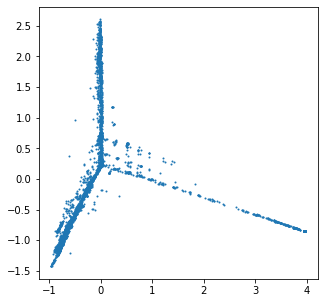

In [47]:
gb = pdf.drop_duplicates().groupby(["focus", "family"], as_index=False).count()
piv = gb.pivot("focus", "family", "protein").fillna(0)
pivb = piv > 0
#calculate distance matrix
#res = pdist(pivb, 'jaccard')
#squareform(res)
#distance = pd.DataFrame(squareform(res), index=pivb.index, columns= pivb.index)
# then use skbio to do pcoA
#results = pcoa(distance)
#pcresults = pd.DataFrame(results.samples)
#pcresults["newname"] = piv.index

X_pca = PCA(n_components=50).fit_transform(pivb)

plt.figure(figsize=[5,5])
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=1
)
plt.show()

In [48]:
X_embedded = TSNE(n_components=2, n_iter=5000,          
                  init='random', perplexity=50).fit_transform(X_pca)
X_df = pd.DataFrame(X_embedded)

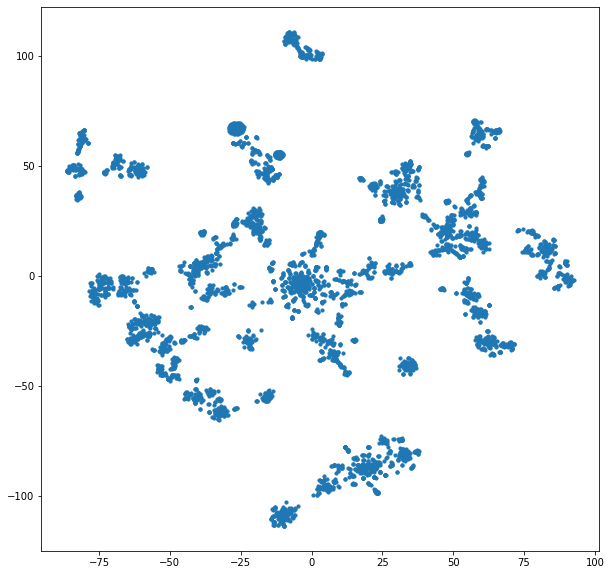

In [96]:
plt.figure(figsize=[10,10])
scatter = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    s=10
)
plt.show()

### annotate protein clusters

In [50]:
import scipy.stats

In [51]:
tmp = {record[0]: record[1] for record in \
          sfp(open(rootdir + "context/neighbors.faa"))}

with open(rootdir + "context/clustering/protein2family.faa", "w") as out:
    
    for protein in pd.read_csv(rootdir + "context/clustering/protein2family.tsv", 
                                sep="\t", header=None)[0].unique():
        out.write(">%s\n%s\n" %(protein, tmp[protein]))

tmp = {}

In [52]:
# launch kofamscan
kocall = "exec_annotation -o %s %s -p %s -k %s --cpu 20 -f detail" \
    %(rootdir + "context/clustering/protein2family.kfscan.txt", rootdir + "context/clustering/protein2family.faa",
     "/home/groups/dekas/software/kofamscan/profiles/prokaryote.hal",
      "/home/groups/dekas/software/kofamscan/ko_list")
print(sbatch("kofamscan", 20, kocall))

sbatch -J kofamscan -p serc -t 1- -c 20 --mem 160G --wrap 'exec_annotation -o /scratch/users/ajaffe/rubisco-div/context/clustering/protein2family.kfscan.txt /scratch/users/ajaffe/rubisco-div/context/clustering/protein2family.faa -p /home/groups/dekas/software/kofamscan/profiles/prokaryote.hal -k /home/groups/dekas/software/kofamscan/ko_list --cpu 20 -f detail'


In [53]:
# filter for significance
kodf = parse.kofamscan(rootdir + "context/clustering/protein2family.kfscan.txt", 1e-5)
kodf["eval"] = kodf["eval"].apply(lambda x: float(x))
kodf["score"] = kodf["score"].apply(lambda x: float(x))
# get best hit per gene based on score
kfilt = kodf.sort_values('score', ascending=False).drop_duplicates("gene")
kfilt["ko"].value_counts()[0:10]

K01601    2879
K23247    1364
K01559    1169
K01602    1119
K21703    1093
K02634     986
K00615     943
K00855     907
K08965     845
K06413     766
Name: ko, dtype: int64

In [54]:
kdf = pdf.merge(kfilt[["gene", "ko", "def"]], how="left", 
                left_on="protein", right_on="gene").fillna("None")

func_info = defaultdict(list)

for family in kdf["family"].unique():
    
    subtable = kdf[kdf["family"]==family]
    func = subtable["def"]
    
    if set(subtable["ko"]) != {'None'}:
    
        mode = scipy.stats.mode(subtable.query("ko!='None'")["ko"])[0][0]
        mode_pct = 100*subtable["ko"].to_list().count(mode)/len(subtable)

        func_info["family"].append(family)
        func_info["family_size"].append(len(subtable))
        func_info["mode_ko"].append(mode)
        func_info["mode_def"].append(subtable[subtable["ko"]==mode]["def"].iloc[0])
        func_info["mode_pct"].append(mode_pct)
    
func_df = pd.DataFrame(func_info).sort_values("mode_pct", ascending=False)

In [55]:
func_df.query("mode_ko=='K01602'")

,family,family_size,mode_ko,mode_def,mode_pct
1165,family11759,529,K01602,ribulose-bisphosphate carboxylase small chain ...,100.0
2590,family26257,286,K01602,ribulose-bisphosphate carboxylase small chain ...,100.0
439,family4355,314,K01602,ribulose-bisphosphate carboxylase small chain ...,100.0


## visualize

### form

In [166]:
palette = {'I': '#b3de69',
 'IPDP': '#69de82',
 'IALP': '#69de82',
 'IIIA': '#ffffb3',
 'IIIB': '#fccde5',
 'IIIC': '#80b1d3',
 'IIILike': '#bebada',
 'IIItrans': '#d9d9d9',
 'II': '#fb8072',       
 'II_III': '#fdb462',
 'RLP_UNK': '#8dd3c7',
 'None': "lightgrey",
 'UNK': "lightgrey"}

In [98]:
centroid_mappings = {row["member_brief"]: row["final_form_assignment"] for key, row in seq_info.iterrows()}

centroid_forms = []

for item in pivb.index:
    
    if item in centroid_mappings:
        centroid_forms.append(centroid_mappings[item])
    else: centroid_forms.append("None")

print(len(set(centroid_mappings.values())))

9


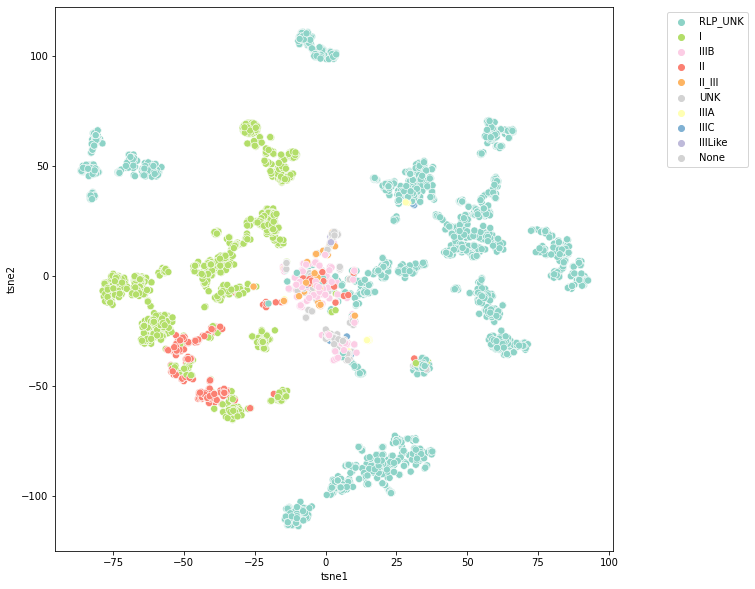

In [99]:
X_df["final_form"] = centroid_forms
X_df.columns = ["tsne1", "tsne2", "final_form"]

plt.figure(figsize=[10,10])
sns.scatterplot(
    data = X_df,#.query("prelim_form=='None'"),
    x = "tsne1",
    y="tsne2",
    color="lightgrey",
    s=10, alpha=0.4
)
sns.scatterplot(
    data = X_df,#.query("final_form!='None'"),
    x = "tsne1",
    y="tsne2",
    hue = "final_form",
    palette=palette,
    s=50, alpha=1
)
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper right')
#plt.savefig(rootdir + "figures/tsne_byform.svg", format="svg")
plt.show()

### context

In [108]:
kos = ["K00855"]
families = func_df[func_df["mode_ko"].isin(kos)]["family"].to_list()

context_mapping = []

for key, row in pivb.iterrows():
    
    flag = False
    
    for column in families:
        if row[column] == True:
            flag=True
    
    context_mapping.append(flag)

X_df["K00855"] = context_mapping

<Figure size 360x360 with 0 Axes>

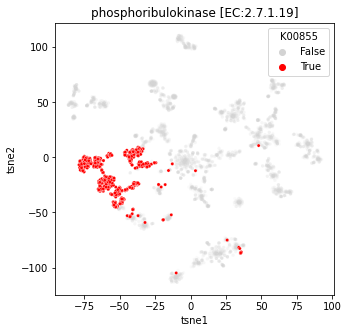

In [109]:
plt.figure(figsize=[5,5])
palette = {True: "red", False: "lightgrey"}

sns.scatterplot(
    data = X_df.query("K00855==False"),
    x = "tsne1",
    y="tsne2",
    hue = "K00855",
    palette=palette,
    s=10, alpha=0.1
)
sns.scatterplot(
    data = X_df.query("K00855==True"),
    x = "tsne1",
    y="tsne2", 
    hue = "K00855",
    palette=palette,
    s=10, alpha=1
)
plt.title(",".join(func_df[func_df["mode_ko"].isin(kos)]["mode_def"].unique()))
#plt.legend(bbox_to_anchor=(1.25, 1), loc='upper right')
#plt.savefig(rootdir + "figures/prk.svg", format="svg")
plt.show()

### taxonomy

In [113]:
taxonomies = {row["rubisco"]: row["domain"] for key, row in context.iterrows()}
#lineages = context.query("domain=='Bacteria'")["phylum"].unique()
#taxonomies = {row["ncbi_rubisco_accession"]: row["ncbi_domain"] for key, row in tsne_md.iterrows()}
values = set(taxonomies.values())
counts = {value: list(taxonomies.values()).count(value) for value in values}

tax_column = []

for key, row in pivb.iterrows():
    
    if key in taxonomies.keys():
        if counts[taxonomies[key]] > 100:
            tax_column.append(taxonomies[key])
        else: tax_column.append("Other")
    else: tax_column.append("None")

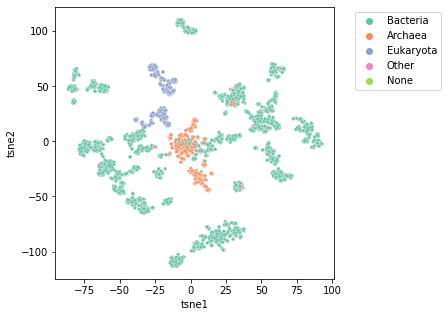

In [114]:
#X_df.columns = ["tsne1", "tsne2", "taxonomy"]
X_df["taxonomy"] = tax_column

plt.figure(figsize=[5,5])
sns.scatterplot(
    data = X_df,
    x = "tsne1",
    y="tsne2", color="lightgrey",
    s=10, alpha=1
)
sns.scatterplot(
    data = X_df,#[X_df["taxonomy"].isin(lineages)],
    x = "tsne1",
    y="tsne2", 
    hue = "taxonomy",
    palette="Set2",
    s=10, alpha=1
)
#plt.ylim([-100,-25])
#plt.xlim([0,60])
plt.legend(bbox_to_anchor=(1.4, 1), loc='upper right')
#plt.savefig(rootdir + "figures/tsne_domain.svg", format="svg")
plt.show()

### make output table

In [116]:
attempted = [line.strip() for line in open(rootdir + "tables/attempted.txt").readlines()]
succeeded = [line.strip() for line in open(rootdir + "tables/succeeded.txt").readlines()]

In [117]:
### generate cluster mapping
final = parse.usearch(rootdir + "sequences/all_rubisco.95.clusters").rename(columns={"sequence":"member"})
#final.to_csv(rootdir + "tables/clusters95.tsv", sep="\t", index=False)

characterized = {}

for centroid in final["centroid"].unique():
    
    attempt = 0
    succeed = 0
    
    members = final[final["centroid"]==centroid]["member"].unique()
    members_clean = ["_".join(item.split("_")[1:]) for item in members]
    
    for member in members_clean:
        
        if member in attempted:
            attempt = 1
        if member in succeeded:
            succeed = 1
            
    if succeed == 1:
        flag = "successful"
    elif attempt == 1:
        flag = "attempted"
    else: flag = "neither"
        
    for member in members_clean:
        characterized[member] = flag

In [160]:
base = X_df
base["rubisco"] = pivb.index
base["cluster_characterization_status"] = base["rubisco"].apply(lambda x: characterized[x])
base = base.merge(context[["filename", "rubisco", "organism", "lineage", "domain"]], how="left", 
                  on="rubisco").fillna("None")
base = base[["rubisco", "final_form", "cluster_characterization_status", "filename", "organism", 
             "lineage", "domain", "K01602", "K00855", "tsne1", "tsne2"]].drop_duplicates()
base.columns = ["ncbi_rubisco_accession", "form_assignment", "cluster_characterization_status", "ncbi_scaffold_accession", 
                "ncbi_organism", "ncbi_lineage", "ncbi_domain", "RbcS", "prk", "tsne_dim_1", "tsne_dim_2"]
base.to_csv(rootdir + "tables/tsne_metadata.tsv", sep="\t", index=False)